In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np
import re
import os
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

print("1. Đang dò tìm đường dẫn và làm sạch dữ liệu...")

# Tự động dò tìm đường dẫn chính xác 100% thay vì gõ cứng
file_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if '20191226-reviews.csv' in filename:
            file_path = os.path.join(dirname, filename)
            break

if file_path is None:
    print("LỖI: Trắng tay! Không tìm thấy file '20191226-reviews.csv'. Bác check lại xem đã Add Data chưa nhé!")
else:
    print(f"-> Đã bắt được file tại: {file_path}")
    
    # Đọc dữ liệu
    df_raw = pd.read_csv(file_path)

    df_sample = df_raw.rename(columns={'body': 'text', 'asin': 'parent_asin', 'name': 'product_name', 'date': 'timestamp'})
    df_sample = df_sample.dropna(subset=['text', 'rating'])

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'<.*?>|http\S+|www\S+|[^a-z0-9\s.,!?]', '', text)
        return re.sub(r'\s+', ' ', text).strip()

    df_sample['clean_text'] = df_sample['text'].apply(clean_text)
    df_sample = df_sample[df_sample['clean_text'].apply(lambda x: len(x.split()) >= 10)]

    def get_sentiment(rating):
        if rating >= 4.0: return 'Positive'
        elif rating == 3.0: return 'Neutral'
        else: return 'Negative'

    df_sample['sentiment'] = df_sample['rating'].apply(get_sentiment)

    print("2. Đang chuẩn bị gói dữ liệu cho Deep Learning (Hugging Face)...")
    X = df_sample['clean_text']
    y = df_sample['sentiment']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    label_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    y_train_encoded = y_train.map(label_mapping)
    y_test_encoded = y_test.map(label_mapping)

    train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train_encoded.tolist()})
    test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test_encoded.tolist()})

    print("3. Đang Tokenize với DistilBERT...")
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_test = test_dataset.map(tokenize_function, batched=True)

    print("\n=> Xong! Môi trường chuẩn xịn. Mời bác chuyển sang Cell tiếp theo để Train model!")

1. Đang dò tìm đường dẫn và làm sạch dữ liệu...
-> Đã bắt được file tại: /kaggle/input/datasets/grikomsn/amazon-cell-phones-reviews/20191226-reviews.csv
2. Đang chuẩn bị gói dữ liệu cho Deep Learning (Hugging Face)...


3. Đang Tokenize với DistilBERT...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/38719 [00:00<?, ? examples/s]

Map:   0%|          | 0/9680 [00:00<?, ? examples/s]


=> Xong! Môi trường chuẩn xịn. Mời bác chuyển sang Cell tiếp theo để Train model!


**Khởi động Lò luyện Deep Learning (Trainer)**

In [4]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import warnings
import torch

# Tắt bớt mấy cảnh báo lặt vặt cho đỡ rối mắt
warnings.filterwarnings("ignore")

print("1. Đang gọi bộ não DistilBERT ra sân (Cấu hình 3 nhãn cảm xúc)...")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

# 2. Hàm tính điểm để model tự chấm bài thi sau mỗi vòng học
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    # Tính F1-score (Macro) - Đây là độ đo quan trọng nhất để trị bệnh mất cân bằng dữ liệu
    f1 = f1_score(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1_macro': f1}

print("\n2. Đang nạp thông số cho Lò luyện (Tối ưu riêng cho GPU Kaggle)...")
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,              # Học 3 vòng (Epoch) để ngấm kiến thức thật sâu
    per_device_train_batch_size=32,  # Nhét 32 câu vào GPU cùng lúc
    per_device_eval_batch_size=64,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",           # <--- ĐÃ SỬA CHỖ NÀY THÀNH eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,     # Giữ lại phiên bản điểm cao nhất
    fp16=True,                       # BẬT TĂNG TỐC PHẦN CỨNG GPU
    report_to="none"                 # Tắt kết nối báo cáo bên ngoài để tránh lỗi
)

# Khởi tạo Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

print("\n🚀 BẮT ĐẦU HUẤN LUYỆN! (Bác đi pha ly cà phê, 5-15 phút nữa quay lại nhé)")
# 3. Kích hoạt quá trình học
trainer.train()

print("\n=> TÈN TEN! Đã huấn luyện xong. Đang làm bài thi kiểm tra cuối kỳ (Test)...")
# 4. Chấm điểm lại trên tập Test lần cuối
results = trainer.evaluate()

print("\n[KẾT QUẢ CỦA TRÙM CUỐI DISTILBERT]")
print(f"Độ chính xác (Accuracy): {results['eval_accuracy'] * 100:.2f}%")
print(f"Điểm F1 Macro: {results['eval_f1_macro'] * 100:.2f}%")

1. Đang gọi bộ não DistilBERT ra sân (Cấu hình 3 nhãn cảm xúc)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



2. Đang nạp thông số cho Lò luyện (Tối ưu riêng cho GPU Kaggle)...

🚀 BẮT ĐẦU HUẤN LUYỆN! (Bác đi pha ly cà phê, 5-15 phút nữa quay lại nhé)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.936651,0.741492,0.859607,0.659150
2,0.634886,0.728453,0.861777,0.698368
3,0.496190,0.818934,0.860640,0.713143


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



=> TÈN TEN! Đã huấn luyện xong. Đang làm bài thi kiểm tra cuối kỳ (Test)...



[KẾT QUẢ CỦA TRÙM CUỐI DISTILBERT]
Độ chính xác (Accuracy): 86.18%
Điểm F1 Macro: 69.84%


Đang trích xuất Báo cáo phân lớp và vẽ Ma trận nhầm lẫn...

[BÁO CÁO PHÂN LỚP CHI TIẾT - TRÙM CUỐI DISTILBERT]
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85      2862
     Neutral       0.38      0.27      0.32       810
    Positive       0.91      0.95      0.93      6008

    accuracy                           0.86      9680
   macro avg       0.71      0.69      0.70      9680
weighted avg       0.85      0.86      0.85      9680



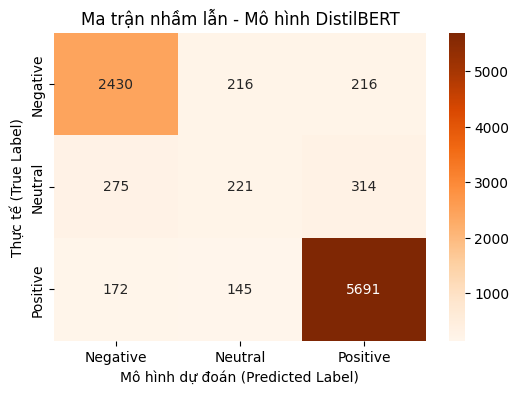

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Đang trích xuất Báo cáo phân lớp và vẽ Ma trận nhầm lẫn...")

# 1. Bắt model lấy tập Test ra dự đoán một lần nữa
predictions = trainer.predict(tokenized_test)
y_pred_dl = np.argmax(predictions.predictions, axis=1)
y_true_dl = predictions.label_ids

target_names = ['Negative', 'Neutral', 'Positive']

# 2. In Báo cáo phân lớp (Classification Report)
print("\n[BÁO CÁO PHÂN LỚP CHI TIẾT - TRÙM CUỐI DISTILBERT]")
print(classification_report(y_true_dl, y_pred_dl, target_names=target_names))

# 3. Vẽ Ma trận nhầm lẫn (Tô màu cam cho khác biệt với Baseline lúc nãy)
cm_dl = confusion_matrix(y_true_dl, y_pred_dl)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Ma trận nhầm lẫn - Mô hình DistilBERT')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Mô hình dự đoán (Predicted Label)')
plt.show()

In [6]:
print("Đang đóng gói và lưu mô hình...")

# Lưu toàn bộ trọng số của model và bộ từ vựng (tokenizer) vào thư mục
trainer.save_model("./amazon_absa_distilbert")
tokenizer.save_pretrained("./amazon_absa_distilbert")

print("Đã lưu thành công vào thư mục: ./amazon_absa_distilbert")
print("Bác nhìn sang cột bên phải (mục Output /kaggle/working), tải thư mục đó về máy tính là XONG!")

Đang đóng gói và lưu mô hình...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu thành công vào thư mục: ./amazon_absa_distilbert
Bác nhìn sang cột bên phải (mục Output /kaggle/working), tải thư mục đó về máy tính là XONG!
